In [1]:
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from typing import TypedDict, Any

d:\genai\venv\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [9]:
#define state 
class GraphState:
    weight: float
    height: float
    bmi: float


In [10]:
def get_bmi(state : GraphState)->GraphState:
    weight = state['weight']
    height = state['height']
    bmi= weight /(height**2)
    state['bmi']=round(bmi,2)
    return state

In [11]:
##define the graph
graph = StateGraph(GraphState)
##add node 
graph.add_node("calculate_bmi",get_bmi)
##add edges 
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi",END)
## compile graph
workflow = graph.compile()

In [16]:
initial_state = {'weight': 70, 'height': 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86}


In [17]:
class BlogState:
    title : str
    outline : str
    content : str

In [33]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY", "")
os.environ["GOOGLE_CSE_ID"] = os.getenv("GOOGLE_CSE_ID", "")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY", "")
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "")

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)

In [48]:
def get_outline(state : BlogState)->BlogState:
    title=state['title']
    prompt = ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant that creates outlines for blogs"),
        ("human",f"Create an outline for a blog with the title {title}")
    ])
    messages = prompt.format_messages()
    outline = llm.invoke(messages)
    state['outline']=outline.content
    return state

In [45]:
def get_content(state: BlogState)->BlogState:
    outline = state['outline']
    title = state['title']
    prompt = ChatPromptTemplate.from_messages([
        ("system","You are a helpful assistant that creates content for blogs based on the outline"),
        ("human",f"Create content for a blog titled {title} with the following outline {outline}")
    ])
    messages = prompt.format_messages()
    content = llm.invoke(messages)
    state['content']=content.content
    return state

In [49]:
graph = StateGraph(BlogState)
## adding the graph node 
graph.add_node("create_outline",get_outline)
graph.add_node("create_blog",get_content)
##adding the edges 
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)
workflow= graph.compile()
 

In [47]:
initial_state = {'title': "Recent Advancement of AI in 2026 software dev industry"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Recent Advancement of AI in 2026 software dev industry', 'outline': 'Here\'s a detailed outline for a blog post titled "Recent Advancement of AI in 2026 Software Dev Industry," focusing on a forward-looking yet realistic perspective.\n\n---\n\n## Blog Post Outline: Recent Advancement of AI in 2026 Software Dev Industry\n\n**Title:** Recent Advancement of AI in 2026 Software Dev Industry\n\n**Target Audience:** Software developers, engineering managers, CTOs, tech enthusiasts, product owners.\n\n**Goal:** To inform readers about the significant, practical ways AI is expected to be integrated into and transform the software development lifecycle by 2026.\n\n---\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Hook:** Start with the rapid, undeniable acceleration of AI\'s impact on every industry, particularly software development.\n*   **B. Current State (Brief):** Briefly acknowledge the current AI tools (e.g., GitHub Copilot, intelligent IDEs) as foundational.\n*  

In [50]:
class aLLM: 
    def __init__(self):
         print('LLM created')
    def predict(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)}

In [52]:
llm = aLLM()

LLM created


In [54]:
class bLLM:
    def __init__(self,template,input):
        self.template= template
        self.input=input
    def format(self,input_dict):
        return self.template.format(**input_dict)
        

In [55]:
from abc import ABC, abstractmethod
class Runnable(ABC):
    @abstractmethod
    def invoke(input_data):
        pass

In [56]:
class nLLM(Runnable): 
    def __init__(self):
         print('LLM created')
    def invoke(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)} 
    def predict(self,prompt):
        response_list=[
            'response1',
            'response2'
        ]
        return {"response":random.choice(response_list)}

In [57]:
class tLLM(Runnable):
    def __init__(self,template,input):
        self.template= template
        self.input=input
    
    def invoke(self,input_dict):
        return self.template.format(**input_dict)
    def format(self,input_dict):
        return self.template.format(**input_dict)

In [58]:
class Chaining(Runnable):
    def __init__(self, *runnables):
        self.runnables = runnables
    
    def invoke(self, input_data):
        for runnable in self.runnables:
            input_data = runnable.invoke(input_data)
        return input_data

In [11]:
##Pararell workflow in langgraph
from pydantic import BaseModel,Field
class BatsmanState(BaseModel):
    runs : int = Field(0, description="Number of runs scored by the batsman")
    balls : int = Field(0, description="Number of balls played by the batsman")
    four : int = Field(0, decription = "Number of fours scored by the batsman")
    six : int = Field(0,description="Number of sixes scored by the batsman")
    bpb: float =Field(0.0,description="Number of boundaries per boundaries")
    boundary_percent : float = Field(0.0, description ="Percentage of runs in boundaries scored by the batsman")
    strike_rate: int = Field(0,description = "Strike rate of the batsman")
    summary : str = Field(...,description = "Summary of batsman performance")
    


C:\Users\soupt\AppData\Local\Temp\ipykernel_13456\470143395.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'decription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  four : int = Field(0, decription = "Number of fours scored by the batsman")


In [22]:
def calculate_sr(state: BatsmanState):
    sr=state['runs']/state['balls']/100
    state['strike_rate']=sr
    return {'sr':sr}

In [23]:
def calculate_bpb(state : BatsmanState):
   bpb =  state['balls']/(state['fours']+state['six'])
   state['bpb']=bpb
   return {'bpb':bpb}

In [24]:
def calculate_boundary_percent(state:BatsmanState):
    boundary_percent = (state['fours']*4 + state['six']*6)/state['runs']*100
    state['boundary_percent']=boundary_percent
    return {'boundary_percent':boundary_percent}

In [25]:
def calculate_summary(state : BatsmanState):
    summary = f"""
      Strike Rate - {state['strike_rate']}
      Balls per boundary- {state['bpb']}
      Boundary Percentage - {state['boundary_percent']}
    """
    state['summary']=summary
    return state
      

In [20]:
graph = StateGraph(BatsmanState)
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('calculate_summary',calculate_summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')
graph.add_edge('calculate_boundary_percent','calculate_summary')
graph.add_edge('calculate_bpb','calculate_summary')
graph.add_edge('calculate_sr','calculate_summary')
graph.add_edge('calculate_summary',END)
workflow= graph.compile()

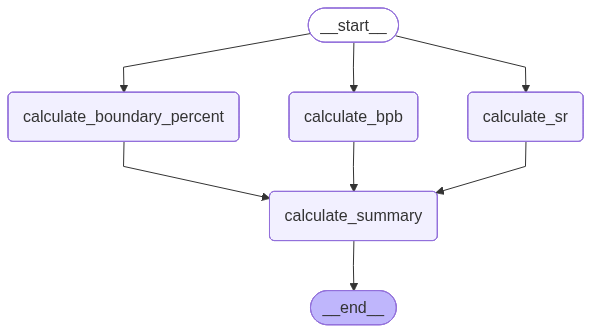

In [21]:
workflow

In [ ]:
initial_state = {
    "runs": 72,
    "balls": 49,
    "four": 8,
    "six": 2,
    "bpb": 0.0,
    "boundary_percent": 0.0,
    "strike_rate": 0.0,
    "summary": ""
}
final_state= workflow.invoke(initial_state)
final_state